In [98]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.impute import SimpleImputer, KNNImputer 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer)
from sklearn.model_selection import train_test_split , GridSearchCV, StratifiedKFold , KFold
from sklearn.metrics import mean_squared_error, r2_score , accuracy_score, precision_score, recall_score, recall_score, f1_score, classification_report, confusion_matrix , precision_recall_fscore_support
from sklearn.neighbors import KNeighborsClassifier
import category_encoders as ce

# **EDA**

In [99]:
df = pd.read_csv(r"D:\Uni_Projects\Ass Machine\Data\car_price.csv")

In [100]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [101]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [102]:
df.shape

(72435, 10)

In [103]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [104]:
df.describe(include="O")

,model,transmission,fuelType,Make
count,68814,68812,68813,68814
unique,145,4,5,7
top,Fiesta,Manual,Petrol,Ford
freq,6225,40839,38390,17045


In [105]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

The dataset exhibits a significant amount of missing data across multiple features. Pre-processing and imputation are required to handle these nulls before proceeding with further analysis or training

<Axes: >

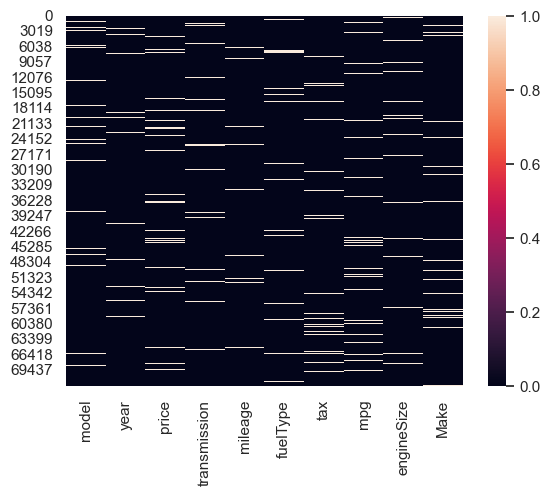

In [106]:
sns.heatmap(df.isnull())

"The heatmap reveals a widespread distribution of missing values across most features, indicating that a significant portion of the rows contains incomplete data which requires careful handling

In [107]:
df = df.dropna(subset=['price']).copy()

In [108]:
print(df['price'].isnull().sum())

0


In [109]:
df.shape

(68814, 10)

In [110]:
df.duplicated().sum()

np.int64(352)

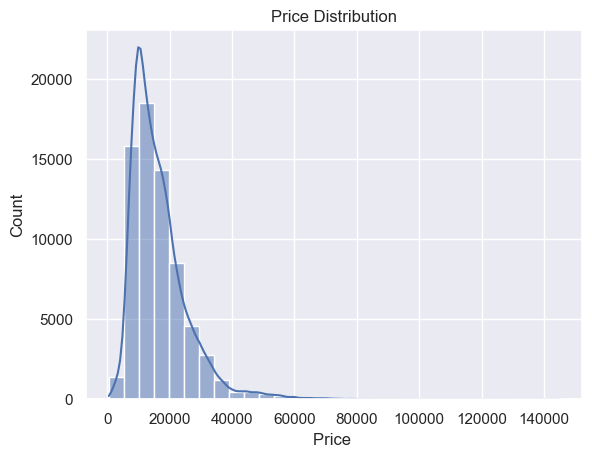

In [111]:
sns.histplot(df['price'], bins=30, kde=True)
plt.xlabel("Price ")
plt.title("Price Distribution")
plt.show()

"The price distribution is positively skewed (right-skewed), indicating that most listings are concentrated at lower price points with a few high-priced outliers forming a long tail.

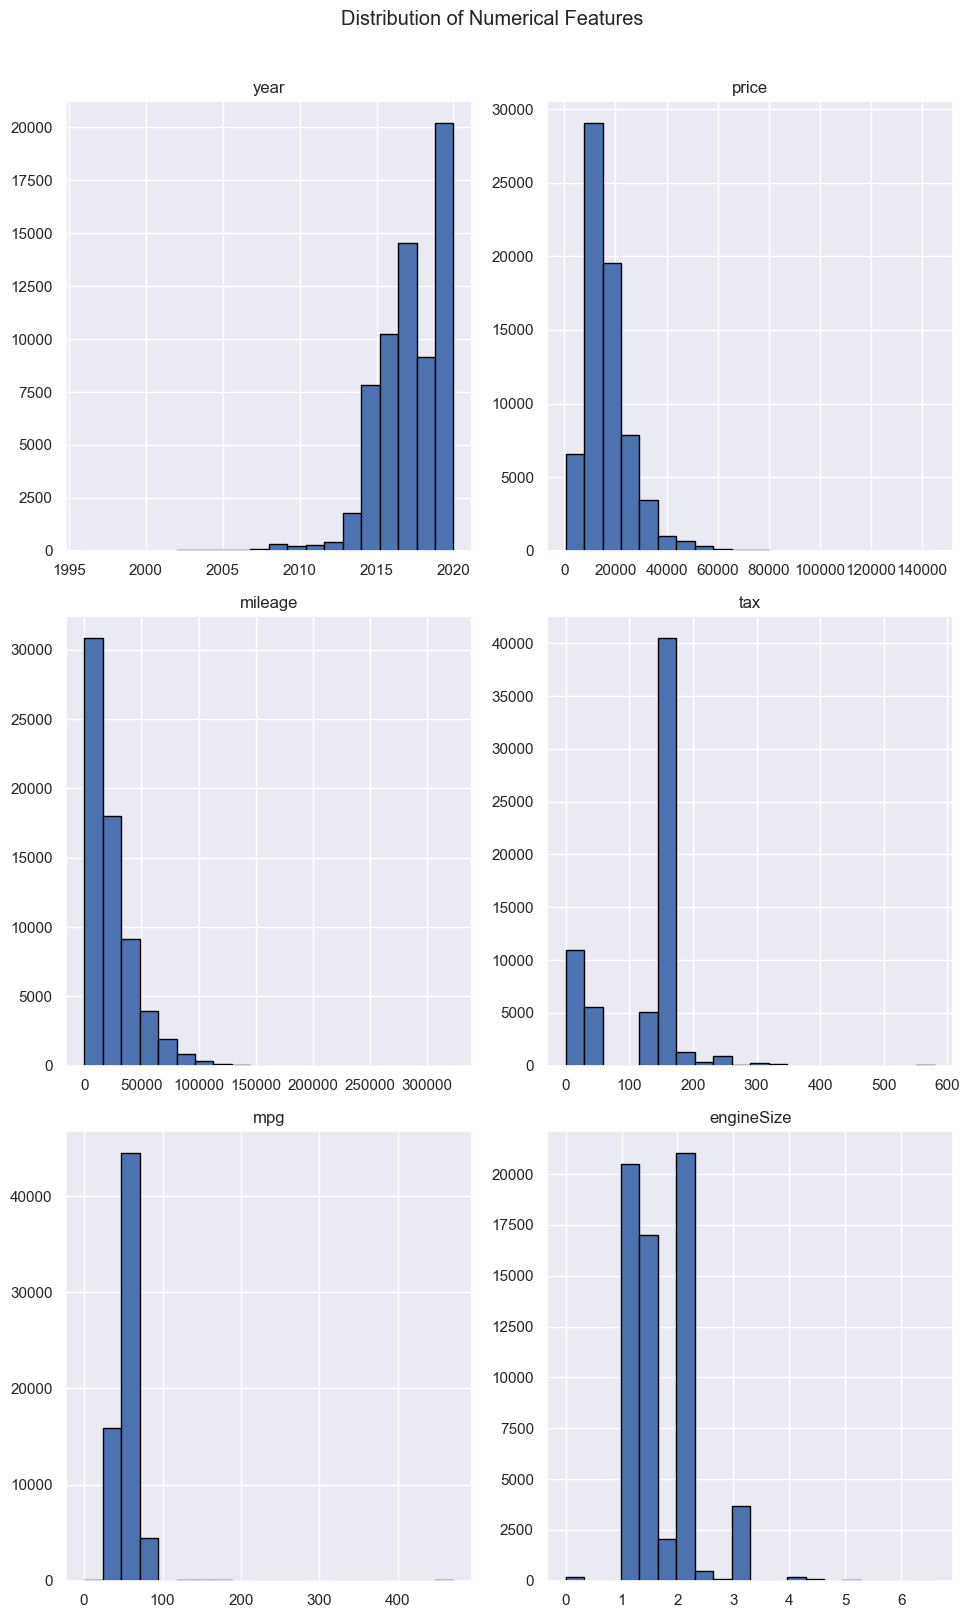

In [112]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
df[num_cols].hist(figsize=(10,16), bins= 20 , edgecolor='black')
plt.suptitle("Distribution of Numerical Features", y=1.01)
plt.tight_layout()
plt.show()

"The numerical features exhibit various non-normal distributions, with most variables being significantly skewed—such as Price and Mileage being right-skewed—highlighting the need for data transformation and scaling before modeling

"Certain features like Tax, EngineSize, and mpg show high concentration around specific discrete values, suggesting standard categorizations or common specifications across the majority of the vehicle records

In [113]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


"The boxplot indicates a uniform price distribution across all car brands. The median prices are relatively consistent, and the interquartile range (IQR) shows similar variability for each brand, suggesting that brand name is not a significant differentiator for price in this dataset.

Text(0.5, 1.0, 'Fuel Type count')

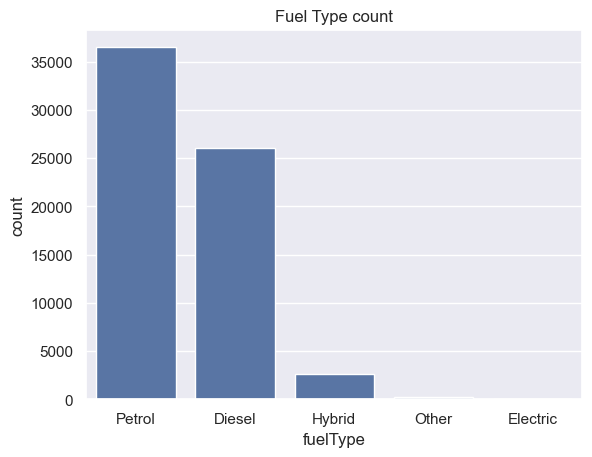

In [114]:
sns.countplot(data=df, x='fuelType')
plt.title("Fuel Type count")

"Petrol is the most prevalent fuel type, followed by Diesel, whereas Hybrid and Electric vehicles represent only a minimal fraction of the total inventory

Text(0.5, 1.0, 'Transmission count')

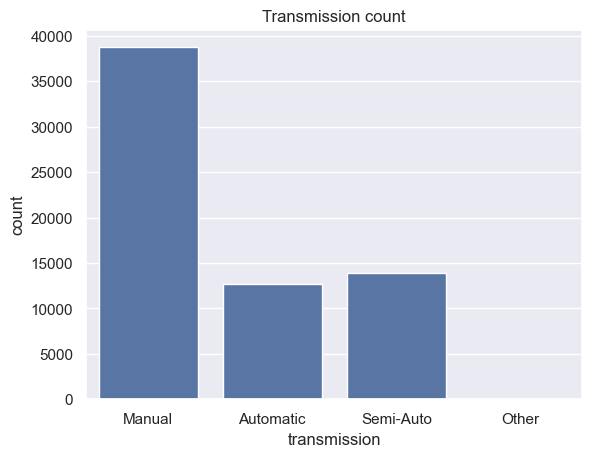

In [115]:
sns.countplot(data= df, x = 'transmission')
plt.title("Transmission count")


"Manual transmissions dominate the dataset, accounting for the vast majority of listings, while Automatic and Semi-Automatic options are significantly less frequent

Text(0.5, 1.0, 'Transmission count')

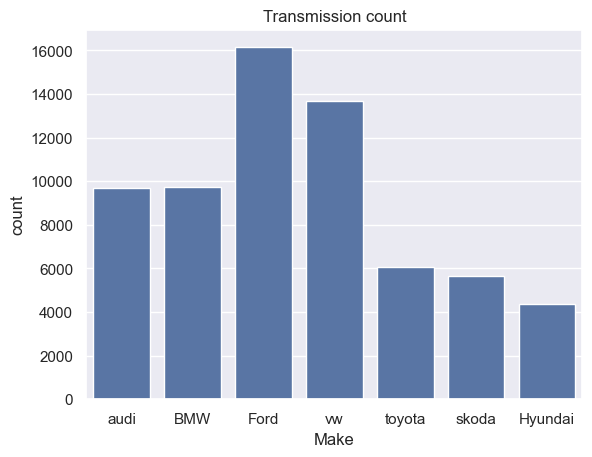

In [116]:
sns.countplot(data= df, x = 'Make')
plt.title("Transmission count")

Ford and VW are the most represented brands in the dataset, while Hyundai shows the lowest count among the listed manufacturers.

In [117]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015.0,7830.0,Manual,NaN,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,NaN
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai


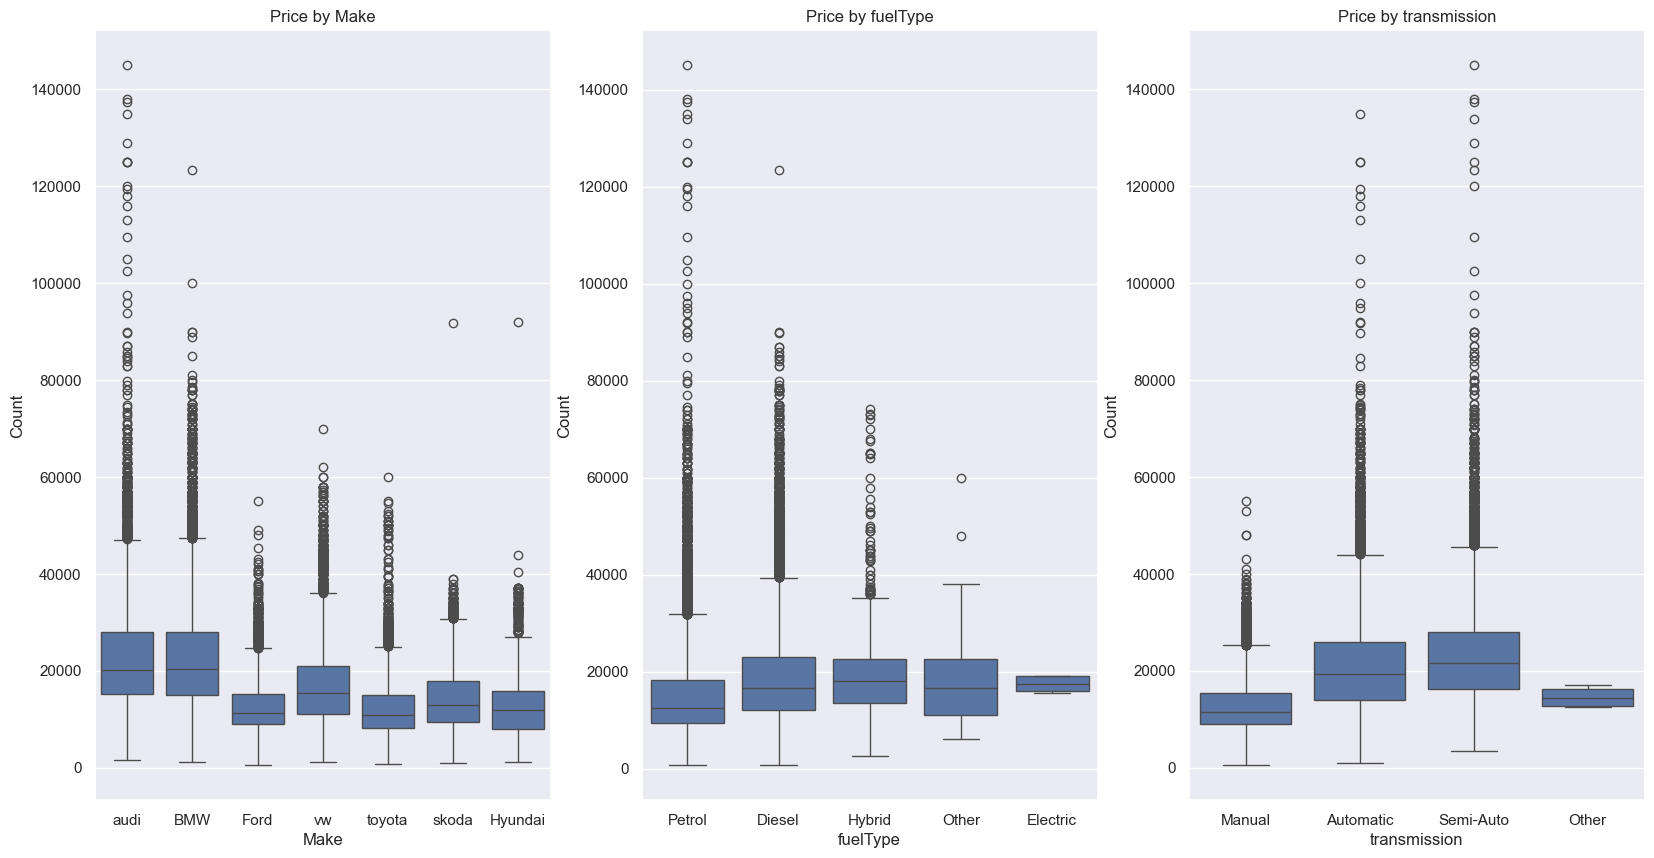

In [118]:
figs,axes =plt.subplots(1,3,figsize=(20,10))
features =['Make', 'fuelType', 'transmission']
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data = df, x=col, y='price',ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.show()

 1 "Premium brands like Audi and BMW exhibit higher median prices and a significant number of high-value outliers

 2 "Hybrid and Diesel vehicles show a slightly higher median price, while Petrol engines account for the widest range of price outliers.
 
 3 "Automatic and Semi-Automatic transmissions command higher market prices than Manual cars, which are concentrated in the lower price segment

"The box plots highlight that vehicle price is significantly influenced by brand, fuel type, and transmission, while also revealing a large presence of extreme outliers across all categories

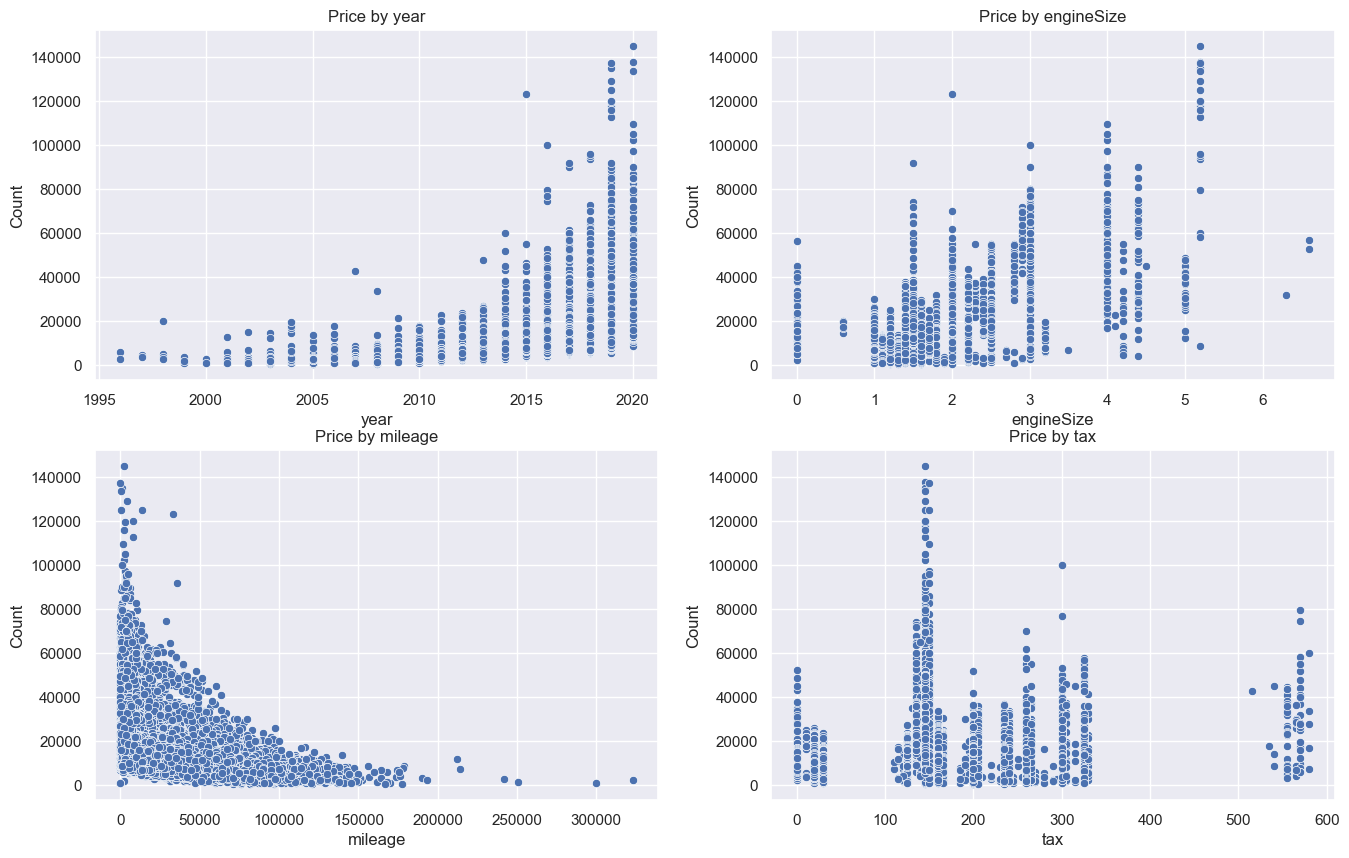

In [119]:
figs,axes =plt.subplots(2,2,figsize=(16,10))
features =['year', 'engineSize', 'mileage','tax','mpg']
for ax, col in zip(axes.flatten(), features):
    sns.scatterplot(data = df, x=col, y='price',ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.show()

1 "There is a strong positive correlation between year and price, as newer models command significantly higher market value

2 "Price shows a clear negative correlation with mileage, where vehicles with lower mileage maintain higher price points.

3 "Larger engine sizes generally correspond to higher price tiers, though the data is clustered around standard engine capacities.

4 "The relationship between tax and price is less linear, with most high-priced listings concentrated within specific tax brackets.

<Axes: >

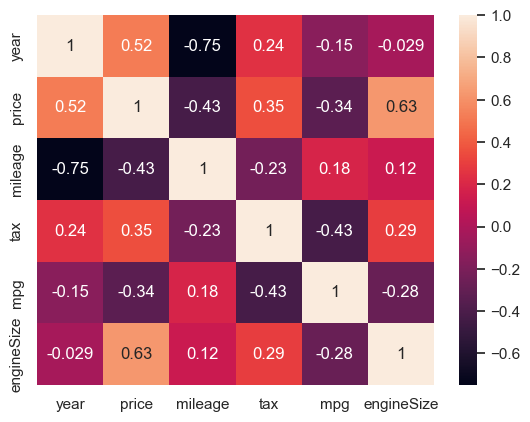

In [120]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

"The heatmap indicates that Price has a strong positive correlation with EngineSize (0.63) and Year (0.52), while showing a notable negative correlation with Mileage (-0.43) and MPG (-0.34)

"Since Year and Mileage are highly correlated (-0.75), we might drop one of them to avoid Multicollinearity, which can destabilize the regression model.

# **Data Preprocessing**

In [121]:
df['car_age'] = 2026 - df['year']
df.drop('year', axis=1, inplace=True)


<Axes: >

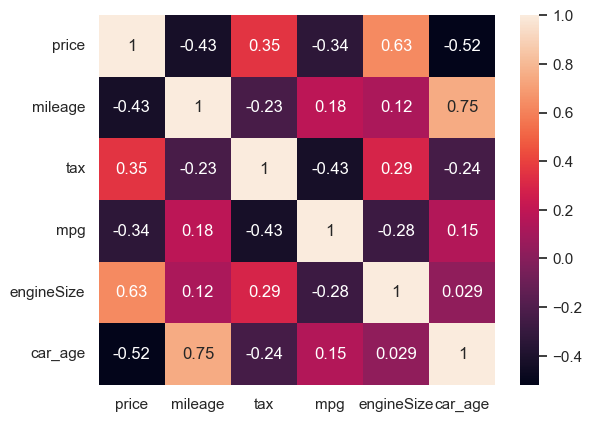

In [122]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

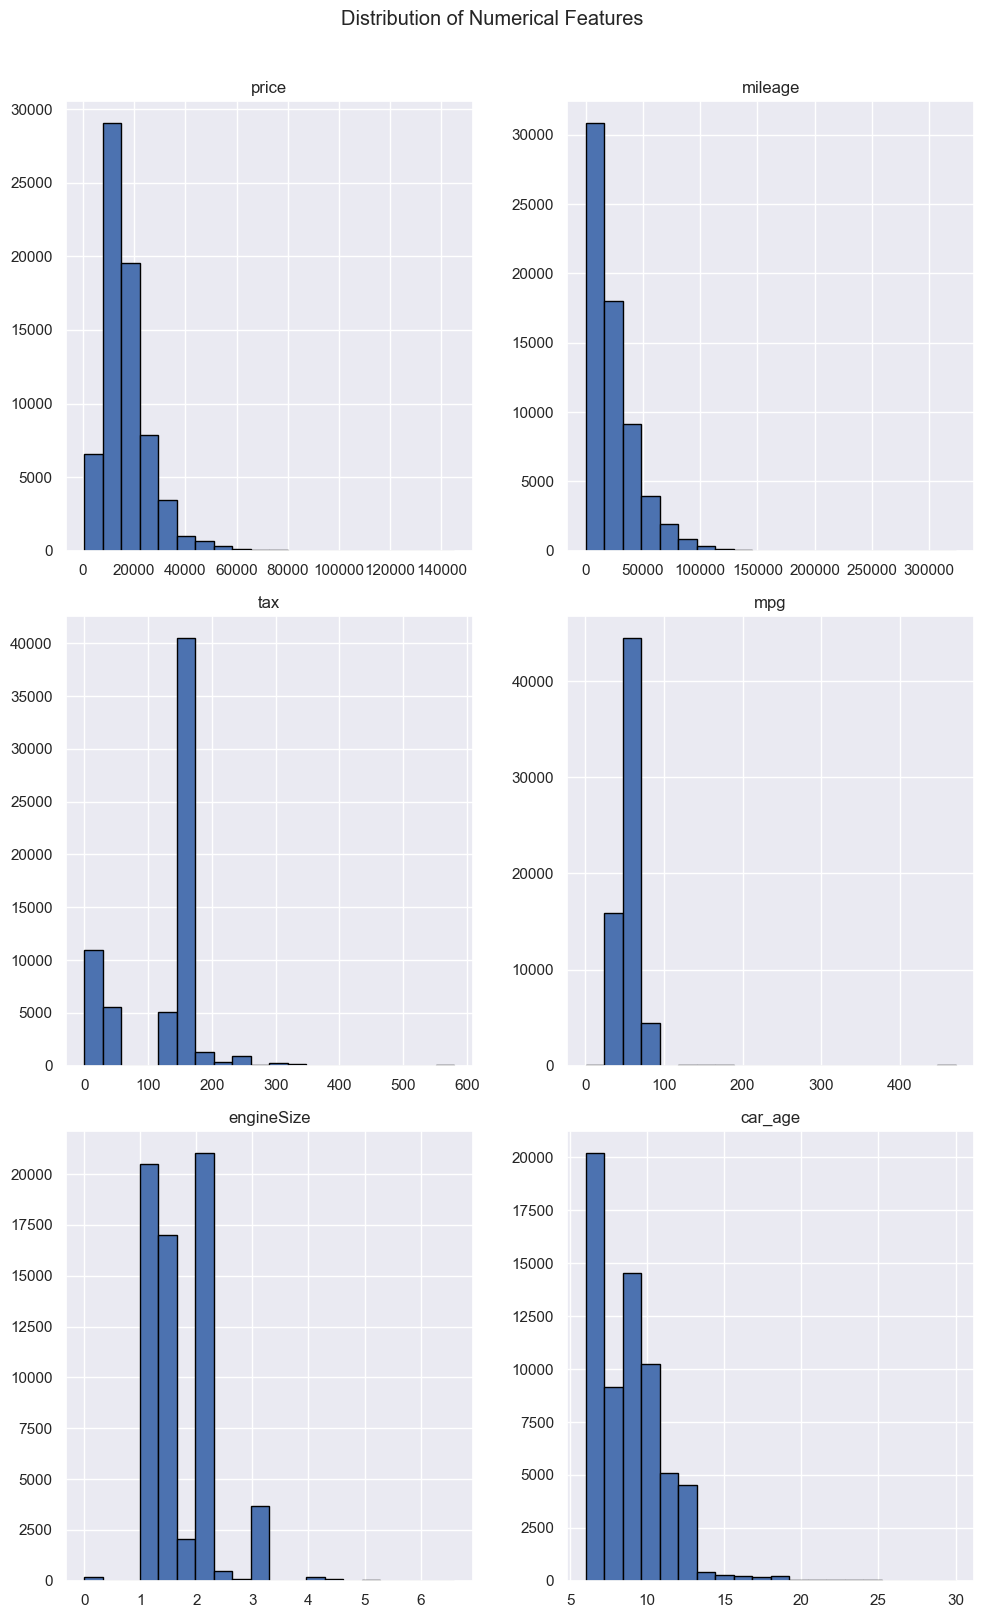

In [123]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
df[num_cols].hist(figsize=(10,16), bins= 20 , edgecolor='black')
plt.suptitle("Distribution of Numerical Features", y=1.01)
plt.tight_layout()
plt.show()

### Train/test split

In [124]:
df.drop_duplicates(inplace=True)

In [125]:
df.duplicated().sum()

np.int64(0)

In [126]:
x = df.drop(columns='price')
y = df[['price']]
x 
y


,price
0,12500.0
1,16500.0
2,11000.0
3,16800.0
4,17300.0
...,...
72430,8680.0
72431,7830.0
72432,6830.0
72433,13994.0


In [127]:
x_train , x_test , y_train , y_test = train_test_split( x, y , test_size=0.2 ,random_state= 1)


In [128]:
print(f"Train: {x_train.shape} | Test: {x_test.shape}")

Train: (54769, 9) | Test: (13693, 9)


# **Outliers Handling & Skewness Transformation** #

<Axes: xlabel='car_age', ylabel='price'>

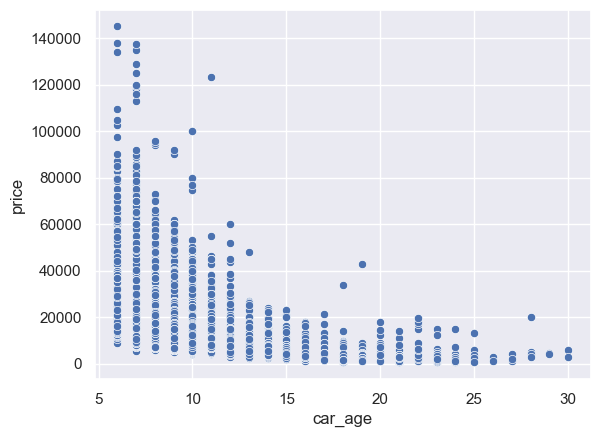

In [129]:
sns.scatterplot(data=df ,x='car_age',y='price')

<Axes: xlabel='car_age', ylabel='Count'>

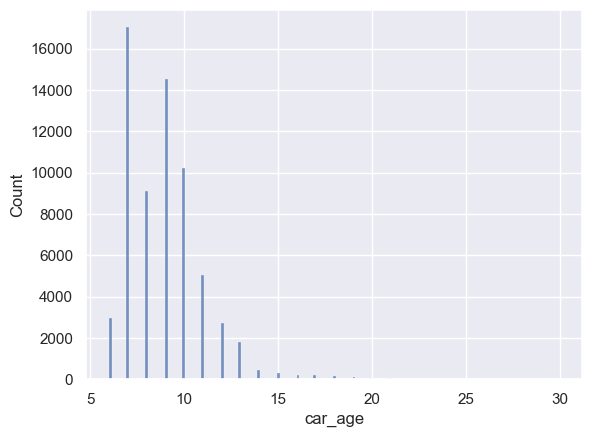

In [130]:
sns.histplot(data=df, x='car_age')

"The 'year' feature was converted into 'car_age' to better capture the depreciation logic, followed by a log transformation to normalize its right-skewed distribution and linearize its relationship with price, which significantly improves the performance of the linear regression model."

In [131]:
x_train

,model,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
41637,Golf,Manual,6000.0,Petrol,145.0,47.9,1.5,NaN,7.0
59289,NaN,Manual,2779.0,Petrol,150.0,68.9,1.0,toyota,8.0
28996,Fiesta,Manual,16520.0,Petrol,145.0,62.8,1.0,Ford,9.0
9012,A3,Automatic,17918.0,Petrol,145.0,47.9,2.0,audi,9.0
7596,A5,Automatic,12062.0,Petrol,145.0,39.8,2.0,audi,7.0
...,...,...,...,...,...,...,...,...,...
51945,Up,Manual,3000.0,Petrol,145.0,54.3,1.0,vw,7.0
21775,Fiesta,Manual,15766.0,NaN,145.0,58.9,1.0,Ford,7.0
22670,Fiesta,Manual,21763.0,Petrol,125.0,54.3,NaN,Ford,10.0
52955,Touareg,NaN,28383.0,Diesel,235.0,42.8,3.0,NaN,9.0


In [132]:
y_train

,price
41637,18900.0
59289,9995.0
28996,10995.0
9012,19299.0
7596,24500.0
...,...
51945,9990.0
21775,11498.0
22670,8640.0
52955,24298.0


In [133]:
skewed_cols = ['mileage','mpg', 'car_age']

for col in skewed_cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])
    
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [134]:
y_train

,price
41637,9.846970
59289,9.209940
28996,9.305287
9012,9.867860
7596,10.106469
...,...
51945,9.209440
21775,9.350015
22670,9.064274
52955,10.098190


IQR outliers in price: 280


C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_16644\1086604592.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers_iqr = y_train[(df['price'] < lower) | (y_train['price'] > upper)]


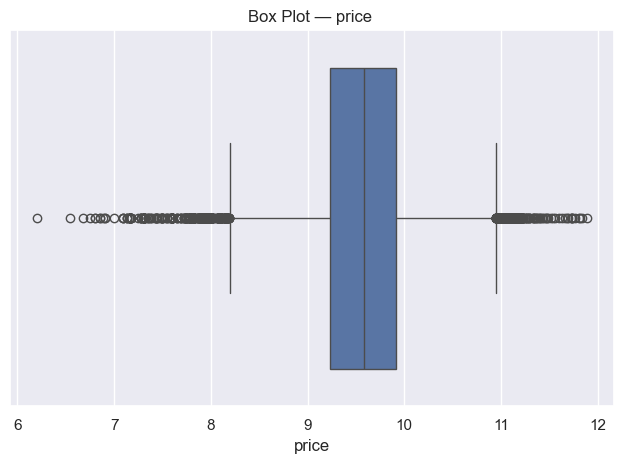

In [135]:
Q1 = y_train['price'].quantile(0.25)
Q3 = y_train['price'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = y_train[(df['price'] < lower) | (y_train['price'] > upper)]
print(f'IQR outliers in price: {len(outliers_iqr)}')
sns.boxplot(data=y_train,x='price')
plt.title('Box Plot — price ')
plt.xlabel('price')
plt.tight_layout()
plt.show()

<Axes: xlabel='price', ylabel='Count'>

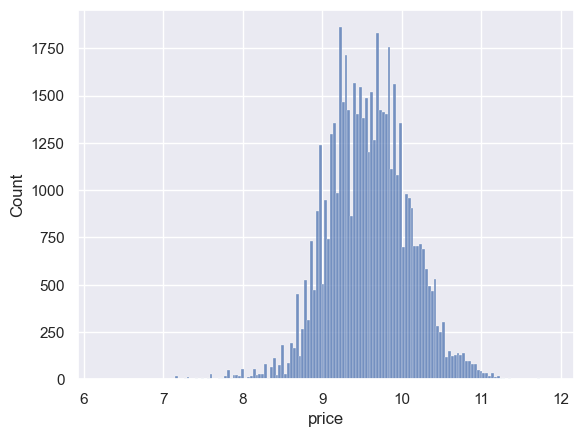

In [136]:
sns.histplot(data=y_train,x='price')

"After applying Log Transformation to the price, the distribution successfully shifted from right-skewed to a normal distribution (Gaussian-like), and the impact of extreme outliers was significantly minimized as shown in the boxplot.

### **Handling Missing Values**

In [137]:
df.isnull().sum()

model           3443
price              0
transmission    3458
mileage         3404
fuelType        3458
tax             3422
mpg             3433
engineSize      3455
Make            3448
car_age         3462
dtype: int64

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68462 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         65019 non-null  object 
 1   price         68462 non-null  float64
 2   transmission  65004 non-null  object 
 3   mileage       65058 non-null  float64
 4   fuelType      65004 non-null  object 
 5   tax           65040 non-null  float64
 6   mpg           65029 non-null  float64
 7   engineSize    65007 non-null  float64
 8   Make          65014 non-null  object 
 9   car_age       65000 non-null  float64
dtypes: float64(6), object(4)
memory usage: 7.8+ MB


In [139]:
df.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
0,A1,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi,9.0
1,A6,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi,10.0
2,A1,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi,10.0
3,A4,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi,9.0
4,A3,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi,7.0


In [140]:
category_col = x_train.select_dtypes(include='O').columns.tolist()
categorical_imputer = SimpleImputer(strategy="most_frequent")
x_train[category_col] = categorical_imputer.fit_transform(x_train[category_col])


In [141]:
x_test[category_col] = categorical_imputer.transform(x_test[category_col])

In [142]:
numeric_col = x_train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy='median')
x_train[numeric_col] = numeric_imputer.fit_transform(x_train[numeric_col])
x_test[numeric_col] = numeric_imputer.transform(x_test[numeric_col])


In [143]:
x_train.head()

,model,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
41637,Golf,Manual,8.699681,Petrol,145.0,3.889777,1.5,Ford,2.079442
59289,Fiesta,Manual,7.930206,Petrol,150.0,4.247066,1.0,toyota,2.197225
28996,Fiesta,Manual,9.712388,Petrol,145.0,4.155753,1.0,Ford,2.302585
9012,A3,Automatic,9.793617,Petrol,145.0,3.889777,2.0,audi,2.302585
7596,A5,Automatic,9.397898,Petrol,145.0,3.708682,2.0,audi,2.079442


In [144]:
x_train.isnull().sum()

model           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
car_age         0
dtype: int64

In [145]:
x_test.isnull().sum()

model           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
car_age         0
dtype: int64

In [146]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54769 entries, 41637 to 5463
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         54769 non-null  object 
 1   transmission  54769 non-null  object 
 2   mileage       54769 non-null  float64
 3   fuelType      54769 non-null  object 
 4   tax           54769 non-null  float64
 5   mpg           54769 non-null  float64
 6   engineSize    54769 non-null  float64
 7   Make          54769 non-null  object 
 8   car_age       54769 non-null  float64
dtypes: float64(5), object(4)
memory usage: 4.2+ MB


"Log transformation was applied to highly skewed numerical features to approximate a normal distribution and stabilize variance, ensuring that the linear regression model is not biased by extreme outliers and can more accurately capture the underlying patterns in the data."

# **Encoding Categorical Variables**

In [147]:
x_train.head()

,model,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
41637,Golf,Manual,8.699681,Petrol,145.0,3.889777,1.5,Ford,2.079442
59289,Fiesta,Manual,7.930206,Petrol,150.0,4.247066,1.0,toyota,2.197225
28996,Fiesta,Manual,9.712388,Petrol,145.0,4.155753,1.0,Ford,2.302585
9012,A3,Automatic,9.793617,Petrol,145.0,3.889777,2.0,audi,2.302585
7596,A5,Automatic,9.397898,Petrol,145.0,3.708682,2.0,audi,2.079442


In [148]:
for col in x_train.select_dtypes(include='O').columns:
    print(f"{col} : {x_train[col].nunique()}")
    print()
    

model : 143

transmission : 4

fuelType : 5

Make : 7



"For categorical features, One-Hot Encoding was applied to 'transmission' and 'fuelType' due to their low cardinality. For 'model' and 'Make', which have high cardinality (144 and 7 unique values),  Label Encoding  or Binary Encoding is preferred to prevent high dimensionality and maintain model performance

In [149]:
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_enc = one_hot.fit_transform(x_train[['transmission' ,'fuelType','Make']])
test_enc = one_hot.transform(x_test[['transmission' ,'fuelType' , 'Make']])

In [150]:
cols_name = one_hot.get_feature_names_out(['transmission' ,'fuelType','Make'])

train_ohe = pd.DataFrame(
 train_enc,
 columns=cols_name,
 index=x_train.index
)
test_ohe = pd.DataFrame(
 test_enc,
 columns=cols_name,
 index=x_test.index
)



In [151]:
x_train = pd.concat(
 [x_train.drop(['transmission' ,'fuelType' , 'Make'], axis=1),
 train_ohe],
 axis=1
)

x_test = pd.concat(
 [x_test.drop(['transmission' ,'fuelType','Make'], axis=1),
 test_ohe],
 axis=1
)


In [152]:
be = ce.BinaryEncoder(cols= 'model')
x_train = be.fit_transform(x_train)
x_test = be.transform(x_test)

"Binary Encoding was used for high-cardinality categorical features like 'model' to reduce dimensionality compared to One-Hot Encoding, and to avoid introducing an artificial order (ordinality) that comes with Label Encoding, which helps maintain model stability and performance

In [153]:
x_train

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,mileage,tax,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
41637,0,0,0,0,0,0,0,1,8.699681,145.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
59289,0,0,0,0,0,0,1,0,7.930206,150.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28996,0,0,0,0,0,0,1,0,9.712388,145.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9012,0,0,0,0,0,0,1,1,9.793617,145.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7596,0,0,0,0,0,1,0,0,9.397898,145.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51945,0,0,0,0,1,1,0,0,8.006701,145.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
21775,0,0,0,0,0,0,1,0,9.665674,145.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
22670,0,0,0,0,0,0,1,0,9.988013,125.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
52955,0,0,0,0,1,0,1,1,10.253581,235.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# **Scale numerical features**

In [154]:
nums_col = [ 'tax', 'engineSize']
scaler = StandardScaler()
x_train[nums_col] = scaler.fit_transform(x_train[nums_col])
x_test[nums_col] = scaler.transform(x_test[nums_col])


In [155]:
x_train.head()

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,mileage,tax,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
41637,0,0,0,0,0,0,0,1,8.699681,0.424458,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
59289,0,0,0,0,0,0,1,0,7.930206,0.503978,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28996,0,0,0,0,0,0,1,0,9.712388,0.424458,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9012,0,0,0,0,0,0,1,1,9.793617,0.424458,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7596,0,0,0,0,0,1,0,0,9.397898,0.424458,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


"The final preprocessed dataset consists of 25 features where categorical variables are binary-encoded and continuous numerical features are log-transformed and standardized. This structure eliminates magnitude bias and ensures the data follows the assumptions required for a high-performing Linear Regression model.

# Multiple Linear Regression Model


In [156]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)
print(x_train.isnull().sum().sum(), x_test.isnull().sum().sum())
print(y_train.isnull().sum().sum(), y_test.isnull().sum().sum())

(54769, 29) (13693, 29)
(54769, 1) (13693, 1)
0 0
0 0


In [157]:
Multi_model = LinearRegression()
Multi_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [158]:
y_train_pred = Multi_model.predict(x_train)

In [159]:
y_train_original = np.expm1(np.ravel(y_train))
y_train_pred_original = np.expm1(np.ravel(y_train_pred))

train_mse = mean_squared_error(y_train_original, y_train_pred_original)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_original, y_train_pred_original)


print("Training MSE:", round(train_mse, 2))
print("Training RMSE:", round(train_rmse, 2))
print("Training R² Score:", round(train_r2, 3))

Training MSE: 16335295.37
Training RMSE: 4041.69
Training R² Score: 0.812


In [160]:
y_pred = Multi_model.predict(x_test)

In [161]:

y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

Convert log-transformed values back to original price scale

# Evaluation Metrics

In [162]:

mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_original)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 14766907.691720722
RMSE: 3842.7734374694433
R² Score: 0.8247322356131711


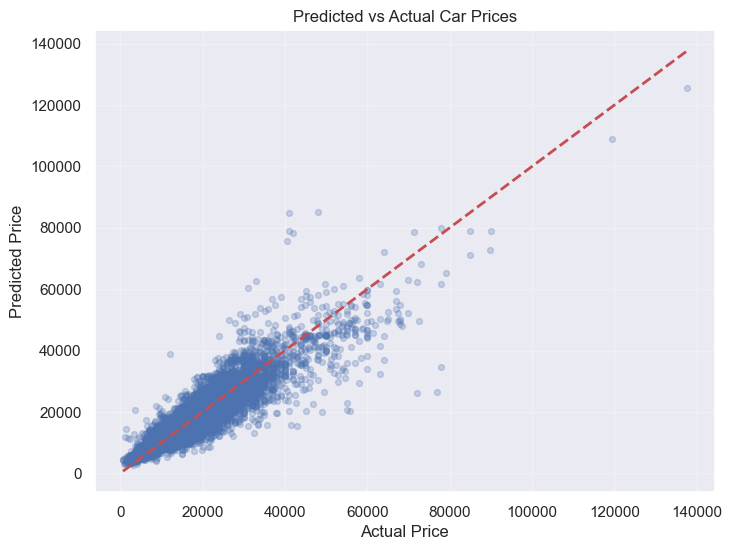

In [163]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_original, y_pred_original, alpha=0.25, s=18)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Car Prices")
plt.grid(alpha=0.3)
plt.show()

 The Actual vs Predicted plot is used to evaluate regression performance.
 It shows how closely the predicted car prices match the actual prices.
 The diagonal red line represents perfect agreement between actual and predicted values.

# KNN Classification


In [164]:
df['price'].describe()

count     68462.000000
mean      16568.548275
std        9298.433764
min         495.000000
25%       10150.000000
50%       14495.000000
75%       20269.750000
max      145000.000000
Name: price, dtype: float64

In [165]:

price=df['price']

In [166]:
p1_25 = price.quantile(0.25)
p2_75 = price.quantile(0.75)

def label_25(price):
    if price < p1_25:
        return 'Cheap'
    elif price < p2_75:
        return 'Moderate'
    else:
        return 'Expensive'

df['cat_25'] = price.apply(label_25)

In [167]:
p1_33 = df['price'].quantile(0.33)
p2_66 = df['price'].quantile(0.66)
def label_33(price):
    if price < p1_33:
        return 'Cheap'
    elif price < p2_66:
        return 'Moderate'
    else:
        return 'Expensive'

df['cat_33'] = price.apply(label_33)

In [168]:
print("=== 25% ===")
print(df['cat_25'].value_counts())

print("\n=== 33% ===")
print(df['cat_33'].value_counts())

=== 25% ===
cat_25
Moderate     34240
Expensive    17116
Cheap        17106
Name: count, dtype: int64

=== 33% ===
cat_33
Expensive    23444
Cheap        22587
Moderate     22431
Name: count, dtype: int64


In [169]:
comparison = pd.concat([
    df['cat_25'].value_counts(),
    df['cat_33'].value_counts()
], axis=1)

comparison.columns = ['25%', '33%']
print(comparison)

             25%    33%
Moderate   34240  22431
Expensive  17116  23444
Cheap      17106  22587


In [170]:
p1=price.quantile(0.33)
p2=price.quantile(0.66)

In [171]:
print(f"Cheap   lower than £{p1:.0f}")
print(f"Moderate  between £{p1:.0f}  and £{p2:.0f}")
print(f"Expensive higher than £{p2:.0f}")

Cheap   lower than £11450
Moderate  between £11450  and £17990
Expensive higher than £17990


In [172]:
def label_price(price):
    if price < p1:
        return 'Cheap'
    elif price < p2:
        return 'Moderate'
    else:
        return 'Expensive'
 
df['cat_33'] = price.apply(label_price)
print("\n=== Number cars in each category ===")
counts = df['cat_33'].value_counts().reindex(['Cheap', 'Moderate', 'Expensive'])
for label, count in counts.items():
    print(f"{label:<10}: {count:,} car")


=== Number cars in each category ===
Cheap     : 22,587 car
Moderate  : 22,431 car
Expensive : 23,444 car


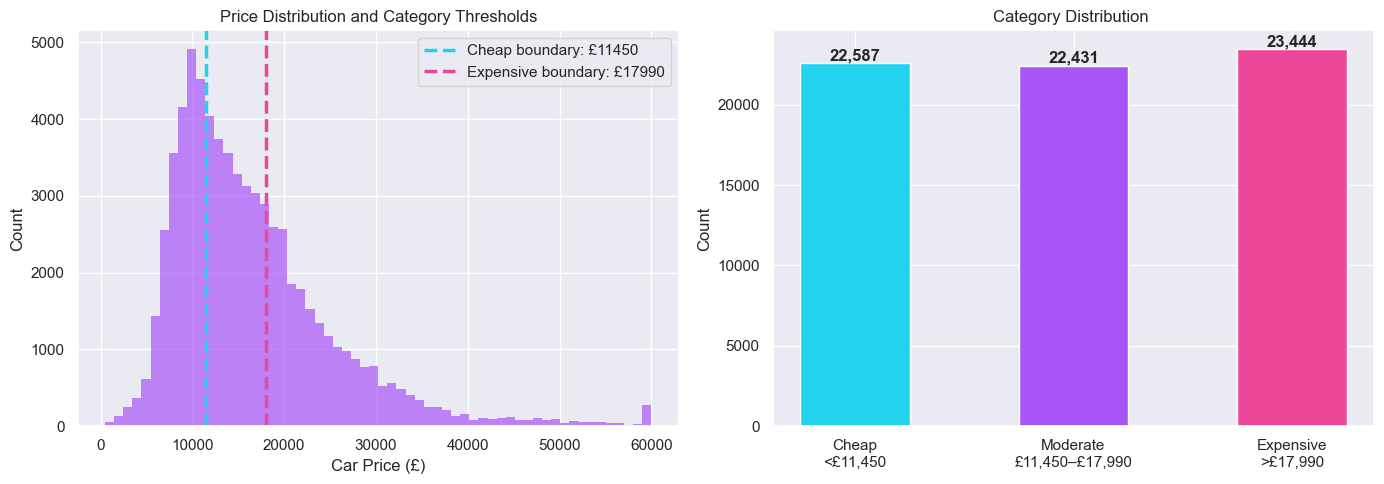

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].hist(price.clip(0, 60000), bins=60,
             color='#a855f7', alpha=0.7, edgecolor='none')
axes[0].axvline(p1, color='#22d3ee', lw=2.5, ls='--',
                label=f'Cheap boundary: £{p1:.0f}')
axes[0].axvline(p2, color='#ec4899', lw=2.5, ls='--',
                label=f'Expensive boundary: £{p2:.0f}')
axes[0].set_title('Price Distribution and Category Thresholds', fontsize=12)
axes[0].set_xlabel('Car Price (£)')
axes[0].set_ylabel('Count')
axes[0].legend()
cat_names = ['Cheap\n<£11,450', 'Moderate\n£11,450–£17,990', 'Expensive\n>£17,990']
bars = axes[1].bar(cat_names, counts.values,
                   color=['#22d3ee', '#a855f7', '#ec4899'], width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Category Distribution ', fontsize=12)
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [174]:
mapping = {
    'Cheap': 0,
    'Moderate': 1,
    'Expensive': 2
}

df['cat_33_encoded'] = df['cat_33'].map(mapping)

In [175]:
X = df.drop(columns=['price', 'cat_33_encoded','cat_25','cat_33'])
y = df['cat_33_encoded']

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [177]:
for col in ['mileage', 'mpg', 'car_age']:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col]  = np.log1p(X_test[col])

print(X_train[['mileage','mpg','car_age']].head(3))

         mileage       mpg   car_age
52514  10.239996  4.070735  2.564949
69135   9.600963  3.708682  2.079442
24830  11.306307  4.112512  2.397895


In [178]:
cat_cols_knn = X_train.select_dtypes(include='O').columns.tolist()
cat_imp = SimpleImputer(strategy='most_frequent')
X_train[cat_cols_knn] = cat_imp.fit_transform(X_train[cat_cols_knn])
X_test[cat_cols_knn]  = cat_imp.transform(X_test[cat_cols_knn])

# Impute numerical → median
num_cols_knn = X_train.select_dtypes(include=np.number).columns.tolist()
num_imp = SimpleImputer(strategy='median')
X_train[num_cols_knn] = num_imp.fit_transform(X_train[num_cols_knn])
X_test[num_cols_knn]  = num_imp.transform(X_test[num_cols_knn])

print("Missing values after imputation:")
print(X_train.isnull().sum().sum(), "nulls in train")
print(X_test.isnull().sum().sum(),  "nulls in test")

Missing values after imputation:
0 nulls in train
0 nulls in test


In [179]:
ohe_knn = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
tr_enc = ohe_knn.fit_transform(X_train[['transmission','fuelType']])
te_enc = ohe_knn.transform(X_test[['transmission','fuelType']])
ohe_cols = ohe_knn.get_feature_names_out(['transmission','fuelType'])

X_train = pd.concat([
    X_train.drop(['transmission','fuelType'], axis=1),
    pd.DataFrame(tr_enc, columns=ohe_cols, index=X_train.index)
], axis=1)
X_test = pd.concat([
    X_test.drop(['transmission','fuelType'], axis=1),
    pd.DataFrame(te_enc, columns=ohe_cols, index=X_test.index)
], axis=1)

be_knn = ce.BinaryEncoder(cols=['Make','model'])
X_train = be_knn.fit_transform(X_train)
X_test  = be_knn.transform(X_test)

print(f"Shape after encoding: {X_train.shape}")
print(X_train.head(2))

Shape after encoding: (54769, 25)
       model_0  model_1  model_2  model_3  model_4  model_5  model_6  model_7  \
52514        0        0        0        0        0        0        0        1   
69135        0        0        0        0        0        0        1        0   

         mileage    tax  ...   car_age  transmission_Automatic  \
52514  10.239996   30.0  ...  2.564949                     0.0   
69135   9.600963  145.0  ...  2.079442                     1.0   

       transmission_Manual  transmission_Other  transmission_Semi-Auto  \
52514                  0.0                 0.0                     1.0   
69135                  0.0                 0.0                     0.0   

       fuelType_Diesel  fuelType_Electric  fuelType_Hybrid  fuelType_Other  \
52514              1.0                0.0              0.0             0.0   
69135              1.0                0.0              0.0             0.0   

       fuelType_Petrol  
52514              0.0  
69135          

In [180]:
sc_knn = StandardScaler()
num_scale = ['mileage','tax','mpg','engineSize','car_age']
X_train[num_scale] = sc_knn.fit_transform(X_train[num_scale])
X_test[num_scale]  = sc_knn.transform(X_test[num_scale])

print(f"Final features: {X_train.shape[1]}")

Final features: 25


In [181]:
print("Preprocessing for KNN done ")

Preprocessing for KNN done 


In [182]:

print(X_train.dtypes[X_train.dtypes == 'object'])

Series([], dtype: object)


In [183]:


param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'metric': ['euclidean', 'manhattan']
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 5}
Best CV Accuracy: 87.61%


In [184]:
gs_results = pd.DataFrame(grid_search.cv_results_)
gs_table = gs_results[['param_n_neighbors','param_metric',
                         'mean_test_score','std_test_score']].copy()
gs_table['mean_test_score'] = (gs_table['mean_test_score']*100).round(3)
gs_table['std_test_score']  = (gs_table['std_test_score']*100).round(4)
gs_table.columns = ['k', 'Metric', 'CV Accuracy (%)', 'Std Dev (%)']
gs_table = gs_table.sort_values('CV Accuracy (%)', ascending=False).reset_index(drop=True)

print("All Grid Search Results:")
print(gs_table.to_string(index=False))

All Grid Search Results:
 k    Metric  CV Accuracy (%)  Std Dev (%)
 5 manhattan           87.612       0.1627
 7 manhattan           87.444       0.2374
 3 manhattan           87.442       0.1817
 9 manhattan           87.422       0.3129
11 manhattan           87.385       0.2632
13 manhattan           87.298       0.2367
 3 euclidean           87.235       0.2068
 5 euclidean           87.201       0.1667
 7 euclidean           87.179       0.2799
 9 euclidean           87.100       0.2444
11 euclidean           87.100       0.2781
13 euclidean           86.974       0.2801


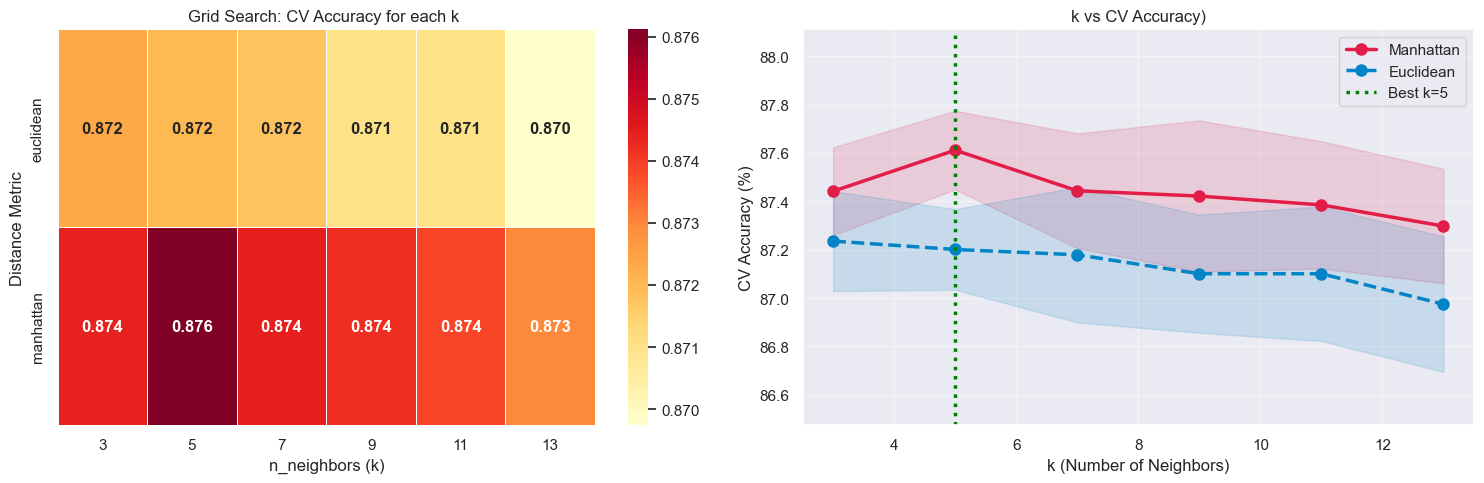

In [185]:
pivot = gs_results.pivot_table(
    values='mean_test_score',
    index='param_metric',
    columns='param_n_neighbors'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5,
            annot_kws={'size':12, 'weight':'bold'})
axes[0].set_title('Grid Search: CV Accuracy for each k ', fontsize=12)
axes[0].set_xlabel('n_neighbors (k)')
axes[0].set_ylabel('Distance Metric')

# Line chart: k vs accuracy
best_k = grid_search.best_params_['n_neighbors']
for metric, color, ls in [('manhattan','#e11d48','-'), ('euclidean','#0284c7','--')]:
    sub = gs_results[gs_results['param_metric']==metric].sort_values('param_n_neighbors')
    ks   = sub['param_n_neighbors'].values
    accs = sub['mean_test_score'].values * 100
    stds = sub['std_test_score'].values * 100
    axes[1].plot(ks, accs, marker='o', color=color, ls=ls, lw=2.5, ms=8, label=metric.capitalize())
    axes[1].fill_between(ks, accs-stds, accs+stds, alpha=0.15, color=color)
    
axes[1].axvline(best_k, color='green', ls=':', lw=2.5, label=f'Best k={best_k}')
axes[1].set_title('k vs CV Accuracy)', fontsize=12)
axes[1].set_xlabel('k (Number of Neighbors)')
axes[1].set_ylabel('CV Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
axes[1].set_ylim(
    gs_results['mean_test_score'].min()*100 - 0.5,
    gs_results['mean_test_score'].max()*100 + 0.5
)

plt.tight_layout()
plt.show()

In [186]:
best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("  Best KNN — Test Set Results")
print("=" * 50)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("=" * 50)

print("\nDetailed Report per class:")
print(classification_report(y_test, y_pred,
      target_names=['Cheap','Moderate','Expensive']))

  Best KNN — Test Set Results
  Accuracy  : 88.02%
  Precision : 88.03%
  Recall    : 88.02%
  F1-Score  : 88.02%

Detailed Report per class:
              precision    recall  f1-score   support

       Cheap       0.91      0.91      0.91      4518
    Moderate       0.82      0.82      0.82      4486
   Expensive       0.92      0.91      0.91      4689

    accuracy                           0.88     13693
   macro avg       0.88      0.88      0.88     13693
weighted avg       0.88      0.88      0.88     13693



In [187]:
print(y_test.unique())

[0 2 1]


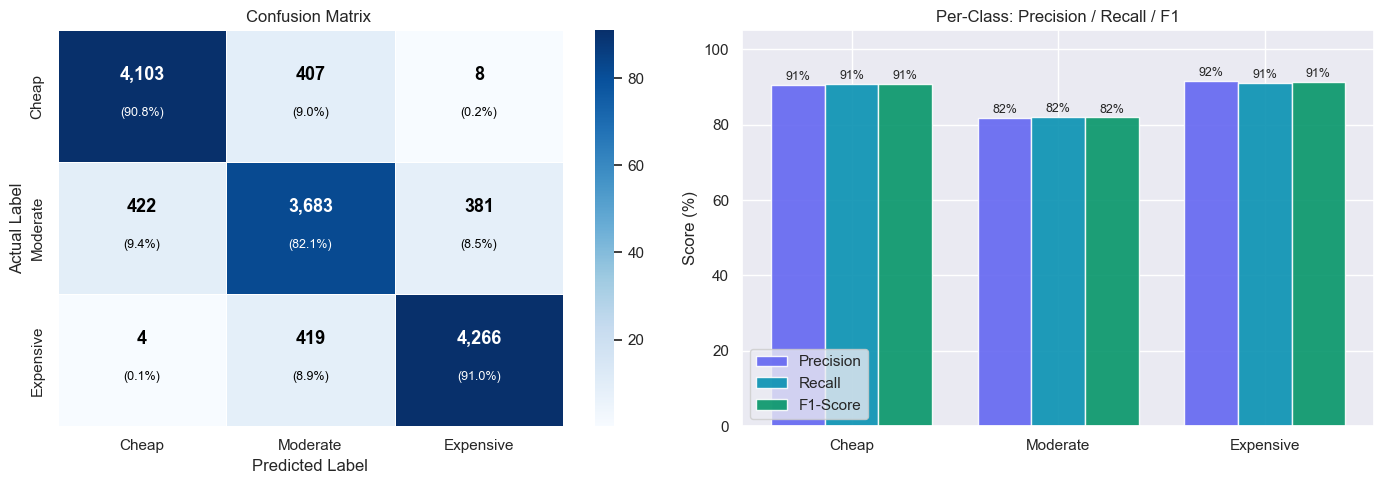

In [188]:
cm = confusion_matrix(y_test, y_pred,
                      labels=[0,1,2])

# نحول لـ percentage (كل صف يجمع 100%)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

cls_labels = ['Cheap', 'Moderate', 'Expensive']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm_pct, annot=False, cmap='Blues', ax=axes[0],
            xticklabels=cls_labels, yticklabels=cls_labels,
            linewidths=0.5)
for i in range(3):
    for j in range(3):
        col_txt = 'white' if cm_pct[i,j] > 45 else 'black'
        axes[0].text(j+0.5, i+0.38, f'{cm[i,j]:,}',
                     ha='center', fontsize=13, fontweight='bold', color=col_txt)
        axes[0].text(j+0.5, i+0.65, f'({cm_pct[i,j]:.1f}%)',
                     ha='center', fontsize=9, color=col_txt)
axes[0].set_title('Confusion Matrix ', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')


# Plot 2: Per-class metrics
p_per, r_per, f_per, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[0,1,2])
x_pos = np.arange(3)
w = 0.26
axes[1].bar(x_pos-w, p_per*100, w, label='Precision', color='#6366f1', alpha=0.9)
axes[1].bar(x_pos,   r_per*100, w, label='Recall',    color='#0891b2', alpha=0.9)
axes[1].bar(x_pos+w, f_per*100, w, label='F1-Score',  color='#059669', alpha=0.9)
for patch in axes[1].patches:
    h = patch.get_height()
    axes[1].text(patch.get_x()+patch.get_width()/2, h+0.5,
                 f'{h:.0f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Cheap','Moderate','Expensive'])
axes[1].set_ylim(0, 105)
axes[1].set_title('Per-Class: Precision / Recall / F1', fontsize=12)
axes[1].set_ylabel('Score (%)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [189]:

print("\nConfusion Matrix Explained:")
print(f"  Cheap    → predicted correctly: {cm[0,0]:,} ({cm_pct[0,0]:.1f}%)")
print(f"  Moderate → predicted correctly: {cm[1,1]:,} ({cm_pct[1,1]:.1f}%)")
print(f"  Expensive→ predicted correctly: {cm[2,2]:,} ({cm_pct[2,2]:.1f}%)")
print(f"\n  Most common error: Moderate misclassified")
print(f"  → as Cheap:     {cm[1,0]:,} cars")
print(f"  → as Expensive: {cm[1,2]:,} cars")
print("  (Expected — Moderate is in the middle, harder to separate)")



Confusion Matrix Explained:
  Cheap    → predicted correctly: 4,103 (90.8%)
  Moderate → predicted correctly: 3,683 (82.1%)
  Expensive→ predicted correctly: 4,266 (91.0%)

  Most common error: Moderate misclassified
  → as Cheap:     422 cars
  → as Expensive: 381 cars
  (Expected — Moderate is in the middle, harder to separate)
